In [27]:
# Latest as of Nov 20 - forked from drugreview_t5_finetuneV5.ipynb

# In this file we will explore some models for analysing medicalabstract dataset from hugging face.
version V3 - consists of experiement with downsample without statify and using ds_test for predicting

In [28]:
import re
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score, f1_score, precision_score,precision_recall_fscore_support, recall_score
from sklearn.metrics import classification_report,precision_recall_fscore_support, accuracy_score,precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from datasets import load_dataset,Dataset,concatenate_datasets
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler

from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

#from datasets import Dataset
import torch

from torch.utils.data import DataLoader, WeightedRandomSampler, TensorDataset

In [29]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [30]:
dryRun = False

In [31]:
from google.colab import drive
drive.mount('/content/gdrive/')

colab_dir = "/content/gdrive/MyDrive/Colab Notebooks/"
base_dir = colab_dir + "d266/FinalProject/"

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


# Load Dataset

In [32]:
# Define the label mapping
label_map = {
    1: "Neoplasms",
    2: "Digestive system diseases",
    3: "Nervous system diseases",
    4: "Cardiovascular diseases",
    5: "General pathological conditions",
}

In [33]:
# Load the dataset and map to text diagnoses
ds = load_dataset("TimSchopf/medical_abstracts")

train, ds_test = ds["train"], ds["test"]
train_df = train.to_pandas()
test_df  = ds_test.to_pandas()

print(f"Original train length: {len(train_df)}")
print(f"Original test length: {len(test_df)}")

Original train length: 11550
Original test length: 2888


In [34]:
# Check for multi-label classification for medical abstracts
(
    train_df.groupby("medical_abstract")["condition_label"]
    .nunique()
    .value_counts()
)


,count
condition_label,
1,7489
2,1810
3,143
4,3


In [35]:
def majority_label_for_each_abstract(df):
    counts = (
        df.groupby(["medical_abstract", "condition_label"])
          .size()
          .reset_index(name="count")
    )

    # For each abstract, find the max count any label got
    counts["max_for_abstract"] = counts.groupby("medical_abstract")["count"].transform("max")

    # Mark which (abstract, label) rows are tied for that max
    counts["is_top"] = counts["count"] == counts["max_for_abstract"]

    # For each abstract, how many labels are tied for top?
    tie_sizes = (
        counts[counts["is_top"]]
        .groupby("medical_abstract")["condition_label"]
        .size()
        .reset_index(name="num_top_labels")
    )

    # Keep only abstracts where there's exactly ONE top label (no tie)
    clean_abstracts = tie_sizes.query("num_top_labels == 1")["medical_abstract"]

    # Filter counts down to only those clean abstracts
    clean_counts = counts[counts["medical_abstract"].isin(clean_abstracts)].copy()

    # Among those, keep only the winning row (the unique top label)
    winners = clean_counts[clean_counts["is_top"]].copy()

    # We now have one (abstract, label) per abstract, guaranteed no ties
    winners = winners[["medical_abstract", "condition_label"]]
    winners = winners.rename(columns={"condition_label": "majority_label"})

    # Optional: shuffle and reset index for cleanliness
    winners = winners.sample(frac=1.0, random_state=42).reset_index(drop=True)

    return winners

In [36]:
train_majority = majority_label_for_each_abstract(train_df)
test_majority  = majority_label_for_each_abstract(test_df)
print("Train size after tie-drop:", len(train_majority))
print("Dropped samples:", len(train_df)-len(train_majority))
print(train_majority["majority_label"].value_counts())
print(train_majority["majority_label"].value_counts(normalize=True))

Train size after tie-drop: 7489
Dropped samples: 4061
majority_label
5    2268
1    1890
4    1723
3     926
2     682
Name: count, dtype: int64
majority_label
5    0.302844
1    0.252370
4    0.230071
3    0.123648
2    0.091067
Name: proportion, dtype: float64


In [37]:
print("Test size after tie-drop:", len(test_majority))
print("Dropped samples:", len(test_df)-len(test_majority))
print(test_majority["majority_label"].value_counts())
print(test_majority["majority_label"].value_counts(normalize=True))

Test size after tie-drop: 2657
Dropped samples: 231
majority_label
5    876
1    599
4    570
3    347
2    265
Name: count, dtype: int64
majority_label
5    0.329695
1    0.225442
4    0.214528
3    0.130598
2    0.099737
Name: proportion, dtype: float64


In [38]:
clean_df = train_majority

train_df_split, val_df_split = train_test_split(
    clean_df,
    test_size=0.3,
    random_state=42,
    stratify=clean_df["majority_label"]
)

train_df_split = train_df_split.reset_index(drop=True)
val_df_split = val_df_split.reset_index(drop=True)

In [39]:
def map_label_to_text(example):
    """Replaces the numerical label with its corresponding text."""
    example["majority_label"] = label_map[example["majority_label"]]
    return example

train_df_split["majority_label_text"] = train_df_split["majority_label"].map(label_map)
print(train_df_split.head())

val_df_split["majority_label_text"] = val_df_split["majority_label"].map(label_map)
print(val_df_split.head())

test_majority["majority_label_text"] = test_majority["majority_label"].map(label_map)
print(test_majority.head())

                                    medical_abstract  majority_label  \
0  A phase I trial of cisplatin in hypertonic sal...               1   
1  Human breast milk contains bovine IgG. Relatio...               2   
2  Periprosthetic chronic inflammation characteri...               5   
3  Effects of endotracheal suctioning on mixed ve...               5   
4  Spongiform encephalopathy transmitted experime...               3   

               majority_label_text  
0                        Neoplasms  
1        Digestive system diseases  
2  General pathological conditions  
3  General pathological conditions  
4          Nervous system diseases  
                                    medical_abstract  majority_label  \
0  Cessation of treatment in advanced cancer. A m...               1   
1  Testicular relapse in children with acute nonl...               1   
2  Community lifestyle characteristics and risk o...               1   
3  Determination of hepatitis B virus DNA in seru...     

In [40]:
# Convert to 0-based ids
labels = sorted(train_df_split["majority_label_text"].unique().tolist())
id2label = {i: txt for i, txt in enumerate(labels)}
label2id = {txt: i for i, txt in enumerate(labels)}

# Map text -> 0-based ints for each split
txt2id = {txt: i for i, txt in enumerate(labels)}
for df in (train_df_split, val_df_split, test_majority):
    df["labels"] = df["majority_label_text"].map(txt2id).astype("int64")

train_ds = Dataset.from_pandas(train_df_split[["medical_abstract","labels"]], preserve_index=False).rename_column("medical_abstract", "text")
val_ds   = Dataset.from_pandas(val_df_split[["medical_abstract","labels"]],   preserve_index=False).rename_column("medical_abstract", "text")
test_ds  = Dataset.from_pandas(test_majority[["medical_abstract","labels"]],  preserve_index=False).rename_column("medical_abstract", "text")

In [41]:
train_ds

Dataset({
    features: ['text', 'labels'],
    num_rows: 5242
})

In [42]:
val_ds

Dataset({
    features: ['text', 'labels'],
    num_rows: 2247
})

In [43]:
print("Train split shape :",train_ds.shape)
#print("Train Label length : ",len(y_train))
print("Val split shape :",val_ds.shape)

Train split shape : (5242, 2)
Val split shape : (2247, 2)


# Define the feature/text and label

# Fine Tuning Section

# Training test splits

# Convert to Hugging Face Dataset

# Define model name and Tokenizer

# Prepare Test data

# Zero-shot prediction
Lets evaluate the pre-trained T5 model as zero-shot classification. Validate if the base model performs better than fine-tuning!!

In [44]:
"""
uncomment this
from transformers import pipeline
t5_model_name = "t5-base"
classifier = pipeline("zero-shot-classification",model=t5_model_name,)


sample_text = df_test["text"]
result = classifier(
    sample_text,
    candidate_labels=["1-2 stars", "3-4 stars", "5-6 stars", "7-8 stars", "9-10 stars"]
)
print("Predicted Probability",result['scores'])
result['labels'][0]
"""
"""
keep it commented
# Zero shot accuracy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score

# ---------------------------
# 1. Load model & tokenizer
# ---------------------------
model_name = "t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")

# ---------------------------
# 2. Example test dataset
# ---------------------------
# Your df_test must contain columns: text, labels
# labels must be strings ("0","1","2","3","4") or ints

df_test = [
    {"text": "The medicine worked great and I feel better", "labels": "4"},
    {"text": "This made me very sick, terrible experience", "labels": "0"},
]

test_ds = Dataset.from_list(df_test)

# ---------------------------
# 3. Zeroshot prediction function
# ---------------------------
def t5_zeroshot_predict(text):
    prompt = f"classify: {text}"

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to("cuda")

    outputs = model.generate(
        **inputs,
        max_length=4,        # label is short
        num_beams=4,
    )

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # clean output (remove any extra text)
    pred = pred.replace(" ", "")
    return pred

# ---------------------------
# 4. Generate predictions for full test set
# ---------------------------
y_true = []
y_pred = []

for row in test_ds:
    true_label = str(row["labels"])
    pred_label = t5_zeroshot_predict(row["text"])

    # optional: restrict to valid label set
    if pred_label not in ["0", "1", "2", "3", "4"]:
        pred_label = "unknown"

    y_true.append(true_label)
    y_pred.append(pred_label)

# ---------------------------
# 5. Compute accuracy
# ---------------------------
acc = accuracy_score(y_true, y_pred)
print("Zero-shot T5-base Accuracy:", acc)

"""


'\nkeep it commented \n# Zero shot accuracy\nfrom transformers import AutoTokenizer, AutoModelForSeq2SeqLM\nimport torch\nfrom datasets import Dataset\nfrom sklearn.metrics import accuracy_score\n\n# ---------------------------\n# 1. Load model & tokenizer\n# ---------------------------\nmodel_name = "t5-base"\ntokenizer = AutoTokenizer.from_pretrained(model_name)\nmodel = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")\n\n# ---------------------------\n# 2. Example test dataset\n# ---------------------------\n# Your df_test must contain columns: text, labels\n# labels must be strings ("0","1","2","3","4") or ints\n\ndf_test = [\n    {"text": "The medicine worked great and I feel better", "labels": "4"},\n    {"text": "This made me very sick, terrible experience", "labels": "0"},\n]\n\ntest_ds = Dataset.from_list(df_test)\n\n# ---------------------------\n# 3. Zeroshot prediction function\n# ---------------------------\ndef t5_zeroshot_predict(text):\n    prompt = f"classi

# Fine Tuning the T5 model with medicalabstract Dataset

## Token config

In [45]:
model_name = "t5-base" # Model name
if os.path.exists(base_dir+"t5_basetoken"):
  print("Loaded base model from local folder:",base_dir+"t5_basetoken")
  tokenizer = AutoTokenizer.from_pretrained(base_dir+"t5_basetoken")
else:
  print("Loading base model from Hugging Face")
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  tokenizer.save_pretrained(base_dir+"t5_basetoken")

Loaded base model from local folder: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5_basetoken


In [46]:
# chanegs for imoproving max_length=2 - > 512
def preprocess_function(examples):
    inputs = ["Classify this review into rating 0–4: " + text for text in examples["text"]]
    # max_length =256
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Convert labels to string tokens
    # padding="max_length"
    with tokenizer.as_target_tokenizer():
        labels = tokenizer([str(label) for label in examples["labels"]],
                           max_length=2, truncation=True, padding=False)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_val = val_ds.map(preprocess_function, batched=True)

#===============================================================
# Use this line when you want to experiment with smaller data set
#===============================================================
if dryRun:
  print("Applying dryRunConfig")
  tokenized_train = tokenized_train.select(range(100))
  tokenized_val = tokenized_val.select(range(20))
  num_train_epochs = 1
  train_batch_size = 4
  val_batch_size = 4
else:
  num_train_epochs = 5
  train_batch_size = 8
  val_batch_size = 16

Map:   0%|          | 0/5242 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

# Load tensorboard dashboard to analyse training

In [47]:
#!rm -rf ./runs #If you see errors like “TensorBoard already running,” clear it with:

#%load_ext tensorboard
#%tensorboard --logdir ./logs

In [48]:
custom_cache_path = base_dir+"t5_basemodel_cache"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = AutoModelForSeq2SeqLM.from_pretrained(model_name,ignore_mismatched_sizes=True,cache_dir=custom_cache_path).to(device)





# Zero-Shot

In [49]:
"""
def t5_zeroshot_predict(text):
    #prompt = f"Classify this review into rating 0–4: {text}"
    #prompt = (
    #    "question: What rating (0,1,2,3,4) best fits this review?\n"
    #    f"review: {text}\n"
    #    "answer:"
    #)
    prompt = (
        "Task: Classify the medical abstract into a rating from 0 to 4.\n"
        "Ratings: 0=Very Bad, 1=Bad, 2=Neutral, 3=Good, 4=Excellent.\n"
        f"Review: {text}\n"
        "Answer with ONLY a single digit (0–4):"
    )
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,padding=False)
    inputs.pop("token_type_ids", None)
    inputs = inputs.to(device)




    model.to(device)
    outputs = model.generate(
        **inputs,
        max_length=2,        # label is short
        num_beams=4,
    )
    print("output",outputs)

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    #print("Pred",)
    # clean output (remove any extra text)
    pred = pred.replace(" ", "")
    return pred

# ---------------------------
# 4. Generate predictions for full test set
# ---------------------------
y_true = []
y_pred = []
from transformers import pipeline
t5_model_name = "t5-base"

df_test = df_test.select(range(15))
tokenized_test = df_test.map(preprocess_function, batched=True)

tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test = tokenized_test.select(range(1))

for row in tokenized_test:
    true_label = str(row["labels"])
    #print("row",row)
    pred_label = t5_zeroshot_predict(row["input_ids"])
    print("what is predlabel",pred_label)
    # optional: restrict to valid label set
    if pred_label not in ["0", "1", "2", "3", "4"]:
        pred_label = "unknown"

    y_true.append(true_label)
    y_pred.append(pred_label)

# ---------------------------
# Compute Metrics
# ---------------------------
#acc = accuracy_score(y_true, y_pred)
#print("Zero-shot T5-base Accuracy:", acc)
# Convert labels to strings (SAFEST)
y_true = [str(y) for y in y_true]
y_pred = [str(y) for y in y_pred]
print(y_pred)
# ---------------------------
# Metrics
# ---------------------------
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", acc)
print("Precision (weighted):", precision)
print("Recall (weighted):", recall)
print("F1 Score (weighted):", f1)

# Optional detailed report
print("\nZero-shot T5-base Classification Report:")
print(classification_report(y_true, y_pred, zero_division=0))
"""

'\ndef t5_zeroshot_predict(text):\n    #prompt = f"Classify this review into rating 0–4: {text}"\n    #prompt = (\n    #    "question: What rating (0,1,2,3,4) best fits this review?\n"\n    #    f"review: {text}\n"\n    #    "answer:"\n    #)\n    prompt = (\n        "Task: Classify the drug review into a rating from 0 to 4.\n"\n        "Ratings: 0=Very Bad, 1=Bad, 2=Neutral, 3=Good, 4=Excellent.\n"\n        f"Review: {text}\n"\n        "Answer with ONLY a single digit (0–4):"\n    )\n    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,padding=False)\n    inputs.pop("token_type_ids", None)\n    inputs = inputs.to(device)\n\n\n\n\n    model.to(device)\n    outputs = model.generate(\n        **inputs,\n        max_length=2,        # label is short\n        num_beams=4,\n    )\n    print("output",outputs)\n\n    pred = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()\n    #print("Pred",)\n    # clean output (remove any extra text)\n    pred = pred.replace(" "

# Define metrics

In [50]:

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Strip spaces, map to ints if possible
    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # Filter invalid preds
    valid = [p for p in decoded_preds if p.isdigit()]
    return {
        "accuracy": accuracy_score(decoded_labels, decoded_preds),
        "precision": precision_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "recall": recall_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "f1": f1_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "macro_f1": f1_score(decoded_labels, decoded_preds, average="macro"),
        "weighted_f1": f1_score(decoded_labels, decoded_preds, average="weighted"),
    }



# Training Starts

In [51]:
model.config.return_dict = True

training_args = Seq2SeqTrainingArguments(
    output_dir=base_dir+"t5_classification",
    seed=42,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=val_batch_size,
    num_train_epochs=num_train_epochs,
    learning_rate=5e-5,#3e-4,5e-5,1e-4
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to=None,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,

    #early_stopping_patience=3,

    # This was added earlier. Accuracy = 0.60
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_dir="./logs",
    logging_steps=10,
    predict_with_generate=True,
    push_to_hub=False,

)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)
print("Training Argument : epoch ",num_train_epochs)
trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-1171542932.py:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Training Argument : epoch  5


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1
1,0.456900,0.402741,0.700045,0.685461,0.663996,0.666903,0.666903,0.693701
2,0.330800,0.358950,0.746328,0.745344,0.715685,0.726678,0.726678,0.744109
3,0.291400,0.350867,0.754339,0.734088,0.758374,0.742868,0.742868,0.748591
4,0.280700,0.374202,0.751669,0.729924,0.769341,0.743576,0.743576,0.744715
5,0.288600,0.374619,0.755674,0.734664,0.769019,0.747592,0.747592,0.749800


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1640, training_loss=0.5581224331041662, metrics={'train_runtime': 1221.412, 'train_samples_per_second': 21.459, 'train_steps_per_second': 1.343, 'total_flos': 3990196577894400.0, 'train_loss': 0.5581224331041662, 'epoch': 5.0})

# Save the model and tokens

In [52]:
base_dir = colab_dir + "d266/FinalProject/"

base_dir+"t5base_finetuned_medicalabstract"

'/content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_drugreviews'

In [53]:

# -------------------------
# 10) Save model and tokenizer
# -------------------------
base_dir = colab_dir + "d266/FinalProject/"

trainer.save_model(base_dir+"t5base_finetuned_medicalabstract")
tokenizer.save_pretrained(base_dir+"t5base_finetuned_medicalabstract")

print(f"Model, tokenizer saved to {base_dir}t5base_finetuned_medicalabstract")

Model, tokenizer saved to /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_drugreviews


# Evaluate

In [54]:
# comment train
metrics = trainer.evaluate()
print("\n=== Evaluation Summary ===")
print(metrics)


=== Evaluation Summary ===
{'eval_loss': 0.3746185600757599, 'eval_accuracy': 0.7556742323097463, 'eval_precision': 0.7346637017317341, 'eval_recall': 0.7690190059308766, 'eval_f1': 0.7475919149829077, 'eval_macro_f1': 0.7475919149829077, 'eval_weighted_f1': 0.7498002443757619, 'eval_runtime': 47.6768, 'eval_samples_per_second': 47.13, 'eval_steps_per_second': 2.957, 'epoch': 5.0}


# Inference/Prediction

In [55]:
test_ds

Dataset({
    features: ['text', 'labels'],
    num_rows: 2657
})

# Tokenize the test data

In [56]:
#tokenized_test  = df_test.map(preprocess_fn, batched=True, remove_columns=["text"])
#preprocess_function
#df_test  = Dataset.from_pandas(test_ds[["text", "rating_bucket"]].rename(columns={"rating_bucket": "labels"}))
#df_test = test_ds.rename(columns={"rating_bucket": "text","":"labels"}))
df_test = test_ds.select(range(15))
tokenized_test = df_test.map(preprocess_function, batched=True)

tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test = tokenized_test.select(range(15))
print("Tokenised test shape : ",tokenized_test.shape)

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenised test shape :  (15, 4)


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [57]:

print("Test eval:")
preds_output = trainer.predict(tokenized_test)
print(preds_output.metrics)
# -------------------------
# Evaluate on test set
# -------------------------
print("Validation eval:")
print(trainer.evaluate(tokenized_val))

Test eval:


{'test_loss': 0.5907605290412903, 'test_accuracy': 0.6, 'test_precision': 0.5933333333333334, 'test_recall': 0.6171428571428571, 'test_f1': 0.5733333333333334, 'test_macro_f1': 0.5733333333333334, 'test_weighted_f1': 0.6088888888888888, 'test_runtime': 0.4157, 'test_samples_per_second': 36.079, 'test_steps_per_second': 2.405}
Validation eval:


{'eval_loss': 0.3746185600757599, 'eval_accuracy': 0.7556742323097463, 'eval_precision': 0.7346637017317341, 'eval_recall': 0.7690190059308766, 'eval_f1': 0.7475919149829077, 'eval_macro_f1': 0.7475919149829077, 'eval_weighted_f1': 0.7498002443757619, 'eval_runtime': 41.1875, 'eval_samples_per_second': 54.555, 'eval_steps_per_second': 3.423, 'epoch': 5.0}


In [58]:
preds_output[0]

array([[  0, 209,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 220,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   3,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 220,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   3,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 220,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 204,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   3,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 314,   1,   0,   0,   0,   0,   0,   0,   0,   0,  

In [59]:
label_values = []
decoded_labels = tokenizer.batch_decode(
    preds_output.label_ids, skip_special_tokens=True
)
print(decoded_labels,len(decoded_labels))

#decoded_labels = [int(l.strip()) for l in decoded_labels]
for l in decoded_labels:
  if l:
    try:
      label_values.append(int(l.strip()))
    except:
      p= 100
  else:
    label_values.append(-100)
print(label_values)
len(label_values)

['2', '3', '2', '3', '', '3', '2', '2', '4', '3', '2', '2', '', '2', '3'] 15
[2, 3, 2, 3, -100, 3, 2, 2, 4, 3, 2, 2, -100, 2, 3]


15

In [60]:
preds_values = []
decoded_preds = tokenizer.batch_decode(
    preds_output.predictions, skip_special_tokens=True
)
#decoded_preds = [int(p.strip()) for p in decoded_preds]
print("!",decoded_preds,len(decoded_preds))
for p in decoded_preds:
  if p:
    try:
        p= int(float(p))   # handles "0", "0.0", "1.0", etc.
    except:
        p= -100

    preds_values.append(p)
print(preds_values)
len(preds_values)


! ['1', '3', '', '3', '', '3', '2', '', '4', '3', '3', '2', '', '1', '2'] 15
[1, 3, 3, 3, 2, 4, 3, 3, 2, 1, 2]


11

In [61]:
for i,pl in enumerate(preds_values):
  print(pl,"->",label_values[i])

1 -> 2
3 -> 3
3 -> 2
3 -> 3
2 -> -100
4 -> 3
3 -> 2
3 -> 2
2 -> 4
1 -> 3
2 -> 2


In [62]:
label_map

{1: 'Neoplasms',
 2: 'Digestive system diseases',
 3: 'Nervous system diseases',
 4: 'Cardiovascular diseases',
 5: 'General pathological conditions'}

In [63]:
decoded_preds

['1', '3', '', '3', '', '3', '2', '', '4', '3', '3', '2', '', '1', '2']

In [64]:

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    "True Label": decoded_labels,
    "Predicted Label": decoded_preds,
    "Text": tokenized_test["input_ids"]  # Replace 'text' with your actual field name
})

# View some mismatches
comparison_df[comparison_df["True Label"] != comparison_df["Predicted Label"]]

,True Label,Predicted Label,Text
0,2,1,"[tensor(4501), tensor(4921), tensor(48), tenso..."
2,2,,"[tensor(4501), tensor(4921), tensor(48), tenso..."
7,2,,"[tensor(4501), tensor(4921), tensor(48), tenso..."
10,2,3,"[tensor(4501), tensor(4921), tensor(48), tenso..."
13,2,1,"[tensor(4501), tensor(4921), tensor(48), tenso..."
14,3,2,"[tensor(4501), tensor(4921), tensor(48), tenso..."


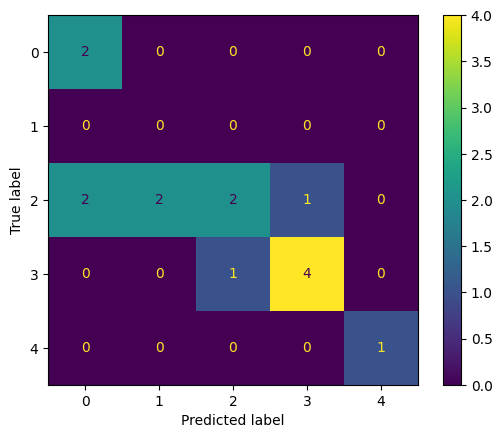

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(decoded_labels, decoded_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()
